# Model C: Behavior Nudging (Autoencoder + DNN Classifier)

**Tahap 1**: Autoencoder untuk segmentasi perilaku belanja.

**Tahap 2**: DNN Classifier untuk prediksi transaksi impulsif berisiko.

**Custom Components (Main Quest)**:
- `WeightedBinaryCrossEntropy` — Custom Loss Function
- `F1EarlyStopping` — Custom Callback

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os, pickle, datetime, warnings
import sys
sys.path.append('..')  # Agar bisa import custom_components
warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
print(f'TensorFlow: {tf.__version__}')

TensorFlow: 2.21.0


In [2]:
# Import Custom Components (Main Quest)
from custom_components import WeightedBinaryCrossEntropy, F1EarlyStopping
print('Custom Loss:', WeightedBinaryCrossEntropy)
print('Custom Callback:', F1EarlyStopping)

Custom Loss: <class 'custom_components.WeightedBinaryCrossEntropy'>
Custom Callback: <class 'custom_components.F1EarlyStopping'>


## 1. Load & Prepare Data

In [3]:
df = pd.read_csv('alice_transactions_final.csv')
df['date'] = pd.to_datetime(df['date'])
df['day_of_week'] = df['date'].dt.dayofweek
df['day_of_month'] = df['date'].dt.day
np.random.seed(42)
df['hour_of_day'] = np.random.choice(range(6, 24), size=len(df))
print(f'Dataset: {len(df)} baris, {df["user_id"].nunique()} user')

Dataset: 142255 baris, 1000 user


## TAHAP 1: Autoencoder
### 2. Feature Engineering

In [4]:
user_feat = df.groupby('user_id').agg(
    avg_spending=('amount', 'mean'),
    total_spending=('amount', 'sum'),
    spending_std=('amount', 'std'),
    monthly_income=('monthly_income', 'first'),
    weekly_budget=('weekly_budget_limit', 'first'),
    impulsive_count=('is_impulsive', 'sum'),
    total_count=('is_impulsive', 'count')
).reset_index()
user_feat['impulsive_ratio'] = user_feat['impulsive_count'] / user_feat['total_count']
user_feat['spending_cv'] = user_feat['spending_std'] / user_feat['avg_spending']
end_month = df[df['day_of_month'] >= 25].groupby('user_id')['amount'].sum().reset_index()
end_month.columns = ['user_id', 'end_month_total']
user_feat = user_feat.merge(end_month, on='user_id', how='left').fillna(0)
user_feat['end_month_ratio'] = user_feat['end_month_total'] / user_feat['total_spending']
weekly = df.groupby(['user_id', 'year', 'week_number']).agg(
    spent=('amount', 'sum'), budget=('weekly_budget_limit', 'first')).reset_index()
weekly['overbudget'] = (weekly['spent'] > weekly['budget']).astype(int)
ob_freq = weekly.groupby('user_id')['overbudget'].mean().reset_index()
ob_freq.columns = ['user_id', 'overbudget_freq']
user_feat = user_feat.merge(ob_freq, on='user_id', how='left')
AE_FEATURES = ['avg_spending', 'impulsive_ratio', 'spending_cv', 'end_month_ratio', 'overbudget_freq']
ae_scaler = StandardScaler()
X_ae = ae_scaler.fit_transform(user_feat[AE_FEATURES].values).astype(np.float32)
print(f'Autoencoder input: {X_ae.shape}')

Autoencoder input: (1000, 5)


### 3. Autoencoder Training

In [5]:
N_FEATURES = X_ae.shape[1]
LATENT_DIM = 2

@keras.saving.register_keras_serializable()
class SpendingAutoencoder(keras.Model):
    def __init__(self, n_features=5, latent_dim=2, **kwargs):
        super().__init__(**kwargs)
        self.n_features = n_features
        self.latent_dim = latent_dim
        self.enc1 = keras.layers.Dense(16, activation='relu')
        self.enc2 = keras.layers.Dense(8, activation='relu')
        self.bottleneck = keras.layers.Dense(latent_dim, activation='relu', name='latent')
        self.dec1 = keras.layers.Dense(8, activation='relu')
        self.dec2 = keras.layers.Dense(16, activation='relu')
        self.dec_out = keras.layers.Dense(n_features)
    def call(self, inputs, training=False):
        latent = self.bottleneck(self.enc2(self.enc1(inputs)))
        return self.dec_out(self.dec2(self.dec1(latent)))
    def encode(self, inputs):
        return self.bottleneck(self.enc2(self.enc1(inputs)))
    def get_config(self):
        c = super().get_config()
        c.update({'n_features': self.n_features, 'latent_dim': self.latent_dim})
        return c

autoencoder = SpendingAutoencoder(n_features=N_FEATURES, latent_dim=LATENT_DIM)
autoencoder(tf.zeros((1, N_FEATURES)))
autoencoder.summary()

Model: "spending_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (1, 16)                │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 8)                 │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (1, 2)                 │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (1, 8)                 │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (1, 16)                │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (1, 5)                 │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 503 (1.96 KB)

 Trainable params: 503 (1.96 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
ae_opt = keras.optimizers.Adam(0.001)
ae_loss_fn = keras.losses.MeanSquaredError()
ae_metric = keras.metrics.Mean()
log_dir = os.path.join('logs', 'autoencoder', datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))
ae_writer = tf.summary.create_file_writer(log_dir)
ae_ds = tf.data.Dataset.from_tensor_slices((X_ae, X_ae)).shuffle(256).batch(32)

@tf.function
def ae_train_step(x, y):
    with tf.GradientTape() as tape:
        loss = ae_loss_fn(y, autoencoder(x, training=True))
    ae_opt.apply_gradients(zip(tape.gradient(loss, autoencoder.trainable_variables), autoencoder.trainable_variables))
    ae_metric.update_state(loss)

for epoch in range(100):
    ae_metric.reset_state()
    for x, y in ae_ds:
        ae_train_step(x, y)
    val = ae_metric.result().numpy()
    with ae_writer.as_default():
        tf.summary.scalar('loss', val, step=epoch)
    if (epoch+1) % 25 == 0:
        print(f'Epoch {epoch+1}/100 | Loss: {val:.6f}')
print('Autoencoder training selesai!')

Epoch 25/100 | Loss: 0.405658
Epoch 50/100 | Loss: 0.365547
Epoch 75/100 | Loss: 0.323346
Epoch 100/100 | Loss: 0.295989
Autoencoder training selesai!


  File "c:\Users\mwija\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\mwija\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 546, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\mwija\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1022, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\mwija\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1491, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


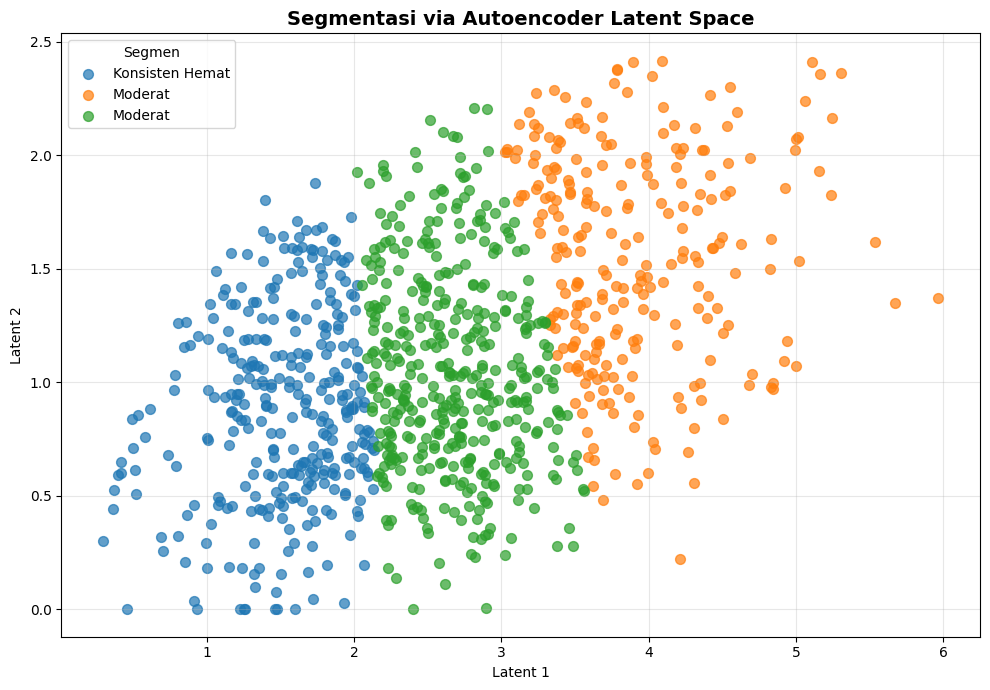

segment
Moderat            676
Konsisten Hemat    324
Name: count, dtype: int64


In [7]:
latent = autoencoder.encode(tf.constant(X_ae)).numpy()
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3, random_state=42, n_init=10)
user_feat['segment'] = km.fit_predict(latent)
seg_names = {}
for s in range(3):
    mask = user_feat['segment'] == s
    imp = user_feat.loc[mask, 'impulsive_ratio'].mean()
    ob = user_feat.loc[mask, 'overbudget_freq'].mean()
    if imp > 0.45: seg_names[s] = 'Impulsif Tinggi'
    elif ob < 0.35: seg_names[s] = 'Konsisten Hemat'
    else: seg_names[s] = 'Moderat'
plt.figure(figsize=(10, 7))
for s in range(3):
    mask = user_feat['segment'] == s
    plt.scatter(latent[mask, 0], latent[mask, 1], label=seg_names[s], alpha=0.7, s=50)
plt.title('Segmentasi via Autoencoder Latent Space', fontsize=14, fontweight='bold')
plt.xlabel('Latent 1'); plt.ylabel('Latent 2')
plt.legend(title='Segmen'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(user_feat['segment'].map(seg_names).value_counts())

## TAHAP 2: DNN Classifier + Custom Components
### 4. Feature Engineering (Diperkaya untuk Akurasi ≥85%)

In [8]:
df_clf = df.merge(user_feat[['user_id', 'segment', 'impulsive_ratio', 'overbudget_freq']], on='user_id', how='left')
user_latent = pd.DataFrame(latent, columns=['latent_1', 'latent_2'])
user_latent['user_id'] = user_feat['user_id'].values
df_clf = df_clf.merge(user_latent, on='user_id', how='left')

# Target
cat_med = df_clf.groupby('category')['amount'].median()
df_clf['cat_median'] = df_clf['category'].map(cat_med)
df_clf['is_risky'] = ((df_clf['is_impulsive'] == 1) & (df_clf['amount'] > df_clf['cat_median'])).astype(int)

# Encode
le = LabelEncoder()
df_clf['cat_enc'] = le.fit_transform(df_clf['category'])
df_clf['weekly_prog'] = df_clf['day_of_week'] / 6
df_clf['monthly_prog'] = df_clf['day_of_month'] / 31

# === FITUR TAMBAHAN untuk meningkatkan akurasi ===
df_clf['amount_norm'] = df_clf['amount'] / df_clf['cat_median']  # Rasio amount vs median kategori
df_clf['is_weekend'] = (df_clf['day_of_week'] >= 5).astype(int)
df_clf['budget_usage'] = df_clf['amount'] / df_clf['weekly_budget_limit']

CLF_FEATURES = ['day_of_week', 'day_of_month', 'hour_of_day', 'segment',
                'cat_enc', 'weekly_prog', 'monthly_prog', 'latent_1', 'latent_2',
                'is_impulsive', 'amount_norm', 'is_weekend', 'budget_usage',
                'impulsive_ratio', 'overbudget_freq']

X = df_clf[CLF_FEATURES].values.astype(np.float32)
y = df_clf['is_risky'].values.astype(np.float32)

clf_scaler = StandardScaler()
X = clf_scaler.fit_transform(X).astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Features: {len(CLF_FEATURES)} kolom')
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Risky ratio: {y.mean()*100:.1f}%')

Features: 15 kolom
Train: (113804, 15), Test: (28451, 15)
Risky ratio: 18.6%


### 5. DNN + Custom Loss + Custom Callback

In [9]:
@keras.saving.register_keras_serializable()
class RiskClassifier(keras.Model):
    def __init__(self, n_features=len(CLF_FEATURES), **kwargs):
        super().__init__(**kwargs)
        self.n_feat = n_features
        self.dense1 = keras.layers.Dense(64, activation='relu')
        self.bn1 = keras.layers.BatchNormalization()
        self.drop1 = keras.layers.Dropout(0.3)
        self.dense2 = keras.layers.Dense(128, activation='relu')
        self.bn2 = keras.layers.BatchNormalization()
        self.drop2 = keras.layers.Dropout(0.3)
        self.dense3 = keras.layers.Dense(64, activation='relu')
        self.drop3 = keras.layers.Dropout(0.2)
        self.out = keras.layers.Dense(1, activation='sigmoid')
    def call(self, inputs, training=False):
        x = self.drop1(self.bn1(self.dense1(inputs), training=training), training=training)
        x = self.drop2(self.bn2(self.dense2(x), training=training), training=training)
        return self.out(self.drop3(self.dense3(x), training=training))
    def get_config(self):
        c = super().get_config(); c.update({'n_features': self.n_feat}); return c

clf_model = RiskClassifier()
clf_model(tf.zeros((1, len(CLF_FEATURES))))
clf_model.summary()

Model: "risk_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (1, 64)                │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (1, 64)                │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (1, 128)               │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (1, 128)               │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (1, 64)                │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (1, 1)                 │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,433 (72.00 KB)

 Trainable params: 18,049 (70.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [10]:
# === Custom Loss Function (Main Quest) ===
neg, pos = np.bincount(y_train.astype(int))
pos_weight = float(neg / pos)
print(f'Class ratio: {neg}:{pos}, pos_weight={pos_weight:.2f}')

# Menggunakan Custom Loss yang sudah didefinisikan
custom_loss = WeightedBinaryCrossEntropy(pos_weight=pos_weight)
print(f'Custom Loss: {custom_loss.name}, pos_weight={custom_loss.pos_weight}')

# === Custom Callback (Main Quest) ===
f1_callback = F1EarlyStopping(patience=15, min_delta=0.001, verbose=True)
f1_callback.set_model_ref(clf_model)

print(f'Custom Callback: F1EarlyStopping, patience={f1_callback.patience}')

Class ratio: 92628:21176, pos_weight=4.37
Custom Loss: weighted_bce, pos_weight=4.37419720438232
Custom Callback: F1EarlyStopping, patience=15


In [11]:
# === Training Loop: GradientTape + Custom Loss + Custom Callback ===
clf_opt = keras.optimizers.Adam(0.0005)
train_loss_m = keras.metrics.Mean()
val_loss_m = keras.metrics.Mean()
val_acc_m = keras.metrics.BinaryAccuracy()
val_recall_m = keras.metrics.Recall()
val_prec_m = keras.metrics.Precision()

log_dir2 = os.path.join('logs', 'risk_clf', datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))
clf_writer = tf.summary.create_file_writer(log_dir2)

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(4096).batch(128)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(128)

clf_history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_recall': [], 'val_f1': []}

@tf.function
def clf_train_step(x, y_true):
    with tf.GradientTape() as tape:
        y_pred = clf_model(x, training=True)
        # Menggunakan Custom Loss Function
        loss = custom_loss(y_true, tf.squeeze(y_pred, axis=-1))
    grads = tape.gradient(loss, clf_model.trainable_variables)
    clf_opt.apply_gradients(zip(grads, clf_model.trainable_variables))
    train_loss_m.update_state(loss)

@tf.function
def clf_val_step(x, y_true):
    y_pred = clf_model(x, training=False)
    loss = custom_loss(y_true, tf.squeeze(y_pred, axis=-1))
    val_loss_m.update_state(loss)
    val_acc_m.update_state(y_true, y_pred)
    val_recall_m.update_state(y_true, y_pred)
    val_prec_m.update_state(y_true, y_pred)

EPOCHS = 100
for epoch in range(EPOCHS):
    train_loss_m.reset_state(); val_loss_m.reset_state()
    val_acc_m.reset_state(); val_recall_m.reset_state(); val_prec_m.reset_state()
    for x, yb in train_ds:
        clf_train_step(x, yb)
    for x, yb in test_ds:
        clf_val_step(x, yb)
    tl = train_loss_m.result().numpy()
    vl = val_loss_m.result().numpy()
    va = val_acc_m.result().numpy()
    vr = val_recall_m.result().numpy()
    vp = val_prec_m.result().numpy()
    f1 = 2*(vp*vr)/(vp+vr) if (vp+vr) > 0 else 0
    clf_history['train_loss'].append(tl)
    clf_history['val_loss'].append(vl)
    clf_history['val_acc'].append(va)
    clf_history['val_recall'].append(vr)
    clf_history['val_f1'].append(f1)
    with clf_writer.as_default():
        tf.summary.scalar('loss', vl, step=epoch)
        tf.summary.scalar('accuracy', va, step=epoch)
        tf.summary.scalar('f1', f1, step=epoch)
    # Custom Callback: cek early stopping
    should_stop = f1_callback.on_epoch_end_manual(epoch, vp, vr)
    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | T.Loss: {tl:.4f} | V.Loss: {vl:.4f} | Acc: {va:.4f} | F1: {f1:.4f} | Recall: {vr:.4f}')
    if should_stop:
        print(f'Early stopping triggered at epoch {epoch+1}')
        break

# Restore best weights dari callback
f1_callback.restore_best_weights(clf_model)
print('\nClassifier training selesai!')

  [F1Callback] F1=0.9431 (best) ✓
  [F1Callback] F1=0.9533 (best) ✓
  [F1Callback] F1=0.9642 (best) ✓
  [F1Callback] F1=0.9722 (best) ✓
  [F1Callback] F1=0.9734 (best) ✓
  [F1Callback] F1=0.9786 (best) ✓
Epoch  10/100 | T.Loss: 0.0381 | V.Loss: 0.0267 | Acc: 0.9871 | F1: 0.9665 | Recall: 0.9987
  [F1Callback] F1=0.9807 (best) ✓
  [F1Callback] F1=0.9825 (best) ✓
  [F1Callback] F1=0.9878 (best) ✓
Epoch  20/100 | T.Loss: 0.0285 | V.Loss: 0.0205 | Acc: 0.9892 | F1: 0.9717 | Recall: 0.9983
  [F1Callback] F1=0.9926 (best) ✓
Epoch  30/100 | T.Loss: 0.0215 | V.Loss: 0.0167 | Acc: 0.9969 | F1: 0.9917 | Recall: 0.9923
  [F1Callback] F1=0.9866 (no improve 13/15)
  [F1Callback] F1=0.9912 (no improve 14/15)
  [F1Callback] F1=0.9758 (no improve 15/15)
  [F1Callback] Early stopping at epoch 39
Early stopping triggered at epoch 39
  [F1Callback] Restored best weights (F1=0.9926)

Classifier training selesai!


### 6. Evaluasi

Threshold: 0.5
Prediksi Risky: 5280 dari 28451

=== Classification Report ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     23157
       Risky       0.99      0.99      0.99      5294

    accuracy                           1.00     28451
   macro avg       1.00      0.99      1.00     28451
weighted avg       1.00      1.00      1.00     28451



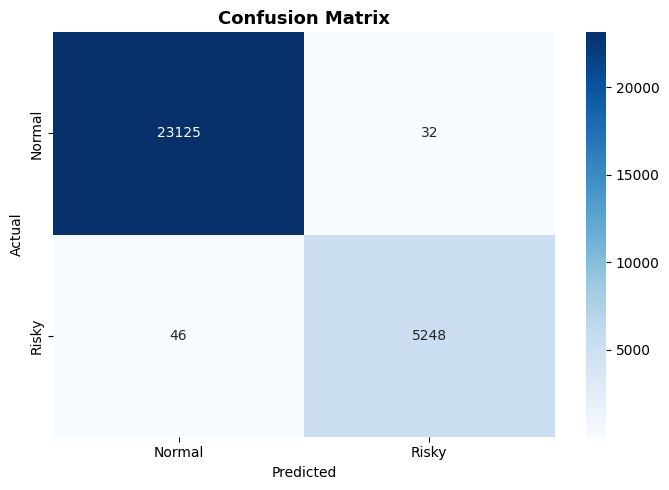

In [12]:
y_pred_prob = clf_model.predict(X_test, verbose=0).flatten()
THRESHOLD = 0.5
y_pred = (y_pred_prob > THRESHOLD).astype(int)

print(f'Threshold: {THRESHOLD}')
print(f'Prediksi Risky: {y_pred.sum()} dari {len(y_pred)}')
print(f'\n=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Normal', 'Risky']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Risky'], yticklabels=['Normal', 'Risky'])
plt.title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

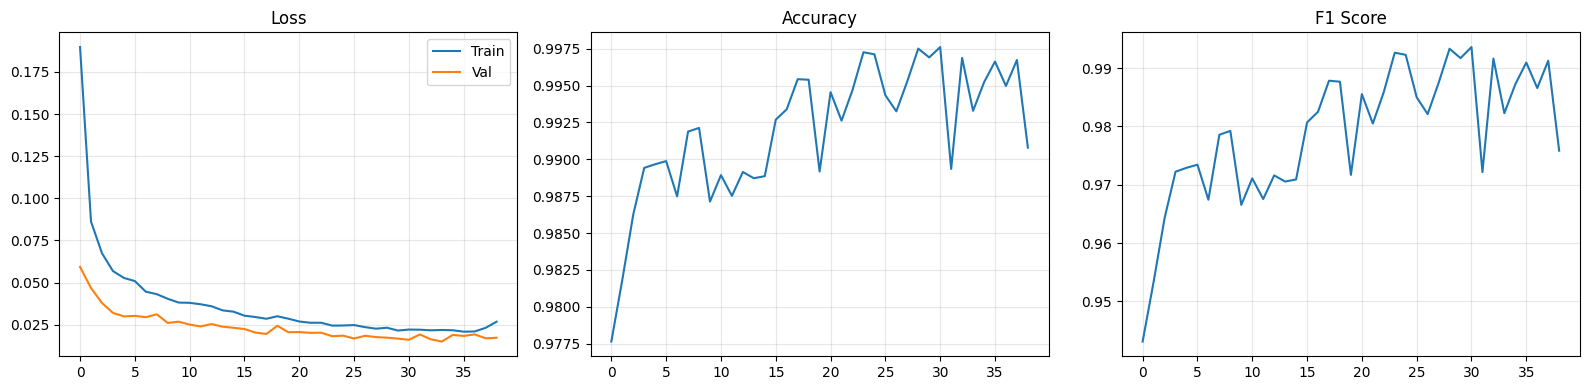

In [13]:
# Training curves
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(clf_history['train_loss'], label='Train'); axes[0].plot(clf_history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(clf_history['val_acc']); axes[1].set_title('Accuracy')
axes[2].plot(clf_history['val_f1']); axes[2].set_title('F1 Score')
for ax in axes: ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

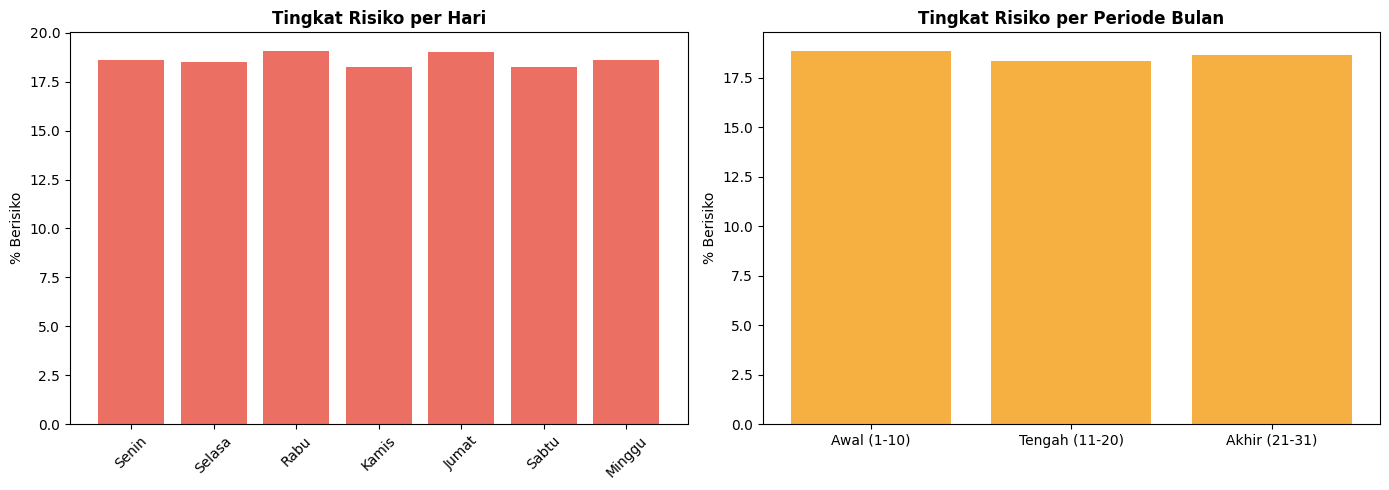

Hari paling berisiko: Rabu
Periode paling berisiko: Awal (1-10)


In [14]:
# Analisis waktu berisiko
day_names = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']
risky_rate = df_clf[df_clf['is_risky']==1].groupby('day_of_week').size() / df_clf.groupby('day_of_week').size() * 100
df_clf['month_period'] = pd.cut(df_clf['day_of_month'], bins=[0,10,20,31],
                                 labels=['Awal (1-10)', 'Tengah (11-20)', 'Akhir (21-31)'])
risky_period = df_clf[df_clf['is_risky']==1].groupby('month_period').size() / df_clf.groupby('month_period').size() * 100
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(day_names, risky_rate.values, color='#e74c3c', alpha=0.8)
axes[0].set_title('Tingkat Risiko per Hari', fontsize=12, fontweight='bold')
axes[0].set_ylabel('% Berisiko'); axes[0].tick_params(axis='x', rotation=45)
axes[1].bar(risky_period.index.astype(str), risky_period.values, color='#f39c12', alpha=0.8)
axes[1].set_title('Tingkat Risiko per Periode Bulan', fontsize=12, fontweight='bold')
axes[1].set_ylabel('% Berisiko')
plt.tight_layout(); plt.show()
print(f'Hari paling berisiko: {day_names[risky_rate.values.argmax()]}')
print(f'Periode paling berisiko: {risky_period.idxmax()}')

### 7. Save Models

In [15]:
os.makedirs('models/saved', exist_ok=True)
autoencoder.save('models/saved/autoencoder_model.keras')
clf_model.save('models/saved/risk_classifier.keras')
with open('models/saved/ae_scaler.pkl', 'wb') as f:
    pickle.dump(ae_scaler, f)
with open('models/saved/clf_scaler.pkl', 'wb') as f:
    pickle.dump(clf_scaler, f)
with open('models/saved/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print('Saved: autoencoder_model.keras, risk_classifier.keras')
print('Saved: ae_scaler.pkl, clf_scaler.pkl, label_encoder.pkl')

Saved: autoencoder_model.keras, risk_classifier.keras
Saved: ae_scaler.pkl, clf_scaler.pkl, label_encoder.pkl


## Custom Components Summary

| Komponen | Class | Deskripsi |
|---|---|---|
| **Custom Loss** | `WeightedBinaryCrossEntropy` | Loss function dengan class weight bawaan |
| **Custom Callback** | `F1EarlyStopping` | Early stopping berdasarkan F1-Score + best weights restore |

Kedua komponen didefinisikan di `custom_components.py` dan digunakan dalam training loop.